# Directional sweeps — the backtest

The strategy as specified:

> Take the position on the sweep's **direction**. Buy the **ATM contract on the next
> third-Friday monthly**. Confirm the signal with the **count of sweeps on that ticker
> in the same direction**. Skip if the holding window contains **earnings**, or if the
> sweep printed on an **FOMC decision day**.

Entry is a real traded option price. Exit is intrinsic value at expiry. No
Black-Scholes anywhere — `backtest_strategy.price_path()` simulates prices from the
underlying, and this deliberately does not.

Signal construction is in
[`directional_sweeps.ipynb`](directional_sweeps.ipynb); this prices it.

## How each trade is priced

| Step | Source |
|---|---|
| Direction | `contractType` x `tradeSideCode` — not call/put alone |
| Expiry | the most-traded listed expiry near each third Friday |
| Strike | nearest to spot among strikes that actually traded |
| **Entry** | first traded option print at or after the sweep, 1-minute bars |
| **Exit** | intrinsic at expiry, off the underlying's close that day |

Two deliberate choices. **Exit is intrinsic, not a final option bar**, because a bar
only exists where the contract traded and a worthless option stops trading before
expiry — marking it off its last print would systematically overstate losers.
**Everything stays in the vendor's unadjusted price space**, so strike and spot are
directly comparable; mixing in Alpaca's split-adjusted bars is what produced the
fictional CRWD +5,368%.

### The expiry bug this surfaced

June 2026's third Friday is the 19th — **Juneteenth** — so the listed monthly moved to
Thursday the 18th. `backtest_strategy.third_friday()` returns the 19th regardless, and
because that backtest prices with Black-Scholes it never noticed it was modelling a
contract that never existed. Expiries here are discovered from the flow instead: the
most-traded listed expiry within three days of each third Friday.

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd() / "research" / "sweep_events"))
import directional as D  # noqa: E402

pd.set_option("display.width", 150, "display.max_columns", 40)

# ---- knobs ----------------------------------------------------------------
MIN_SAME_DIR  = 0        # require >= this many prior same-direction sweeps
MIN_NET_DIR   = None     # or require (same - opposite) >= this
MIN_CONVICTION = None    # or require aligned conviction >= this
MAX_COST      = None     # $/contract cap, None = no cap
OOS_SPLIT     = "2026-08-15"
# ---------------------------------------------------------------------------

trades = pd.read_parquet("/Users/kunjshah/Downloads/pxq_stocks/data/directional_trades.parquet")
flow = D.load()
feat = D.confirm(flow, D.triggers(flow))

# `triggers()` already attaches entry_ts as naive New York wall-clock
key = ["ticker", "session", "entry_ts"]
trades["entry_ts"] = pd.to_datetime(trades["entry_ts"])
cols = ["prior_n", "same_dir_n", "opp_dir_n", "net_dir_n", "conviction", "aligned"]
trades = trades.merge(feat[key + cols].drop_duplicates(key), on=key, how="left")

print(f"{len(trades)} triggers considered")

441 triggers considered


In [36]:
mkt_cap = pd.read_parquet('/Users/kunjshah/Downloads/pxq_stocks/data/market_cap.parquet')

In [37]:
mkt_cap.rename(columns={'symbol':'ticker'}, inplace=True)

In [83]:
df = trades.merge(mkt_cap, on="ticker", how="left")

In [84]:
df['cap_bucket'].value_counts()

cap_bucket
Mega cap     310
Large cap    121
Mid cap        6
Small cap      4
Micro cap      0
Name: count, dtype: int64

In [64]:
small_cap = df[df['cap_bucket']=='Small cap']
small_cap['ticker']

33     POET
158    EOSE
271     RAM
273    NRGV
Name: ticker, dtype: object

In [78]:
small_cap

,ticker,session,entry_ts,direction,sweep_premium,sweep_delta,entry_spot,prior_n_x,skip,expiry,right,strike,entry_price,entry_volume,exit_spot,exit_price,ret,contract_cost,prior_n_y,same_dir_n,opp_dir_n,net_dir_n,conviction,aligned,market_cap,sector,industry,cap_bucket,is_fund,asof_date
33,POET,2026-06-04,2026-06-04 13:54:16.565,BULL,1077090.0,0.484058,15.49,NaN,None,2026-06-18,CALL,15.0,1.88,3159.0,12.17,0.0,-1.0,188.0,1,1,0,1,1.0,1.0,1.413885e+09,Producer Manufacturing,Electrical Products,Small cap,False,2026-09-22
158,EOSE,2026-07-01,2026-07-01 11:11:22.182,BULL,1414510.0,0.316965,5.75,NaN,None,2026-07-17,CALL,5.0,0.82,1.0,4.12,0.0,-1.0,82.0,0,0,0,0,NaN,NaN,1.480343e+09,Producer Manufacturing,Electrical Products,Small cap,False,2026-09-22
271,RAM,2026-07-24,2026-07-24 10:37:51.076,BEAR,2280000.0,0.408569,12.34,NaN,no_earnings_coverage,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN,NaN,6.912000e+08,Miscellaneous,Investment Trusts Or Mutual Funds,Small cap,True,2026-09-22
273,NRGV,2026-07-24,2026-07-24 15:47:42.244,BEAR,1092810.0,0.672752,2.90,NaN,earnings_in_window,2026-08-21,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN,NaN,8.664676e+08,Producer Manufacturing,Electrical Products,Small cap,False,2026-09-22


In [47]:
small_cap
def small_cap_signal(ticker):
    df = small_cap[small_cap['ticker']==ticker]
    return df

In [75]:
RAM = small_cap_signal(ticker = 'NRGV')
RAM

,ticker,session,entry_ts,direction,sweep_premium,sweep_delta,entry_spot,prior_n_x,skip,expiry,right,strike,entry_price,entry_volume,exit_spot,exit_price,ret,contract_cost,prior_n_y,same_dir_n,opp_dir_n,net_dir_n,conviction,aligned,market_cap,sector,industry,cap_bucket,is_fund,asof_date
273,NRGV,2026-07-24,2026-07-24 15:47:42.244,BEAR,1092810.0,0.672752,2.9,NaN,earnings_in_window,2026-08-21,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN,NaN,866467600.0,Producer Manufacturing,Electrical Products,Small cap,False,2026-09-22


In [76]:
from backtest.data import load_bars
panel = load_bars("NRGV", "2026-07-24", "2026-07-27", timeframe="1Hour", session="regular")
close = panel.field("close")

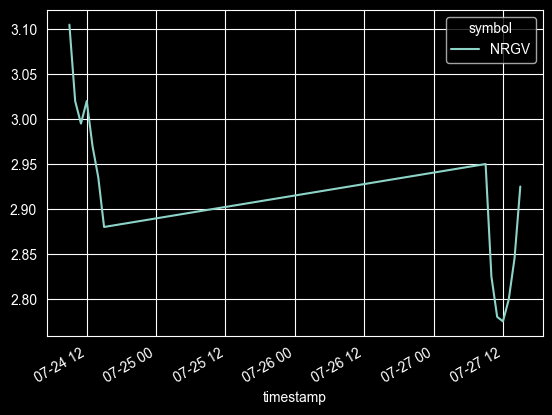

In [77]:
import matplotlib.pyplot as plt
from backtest.data import load_bars
panel = load_bars("NRGV", "2026-07-24", "2026-07-27", timeframe="1Hour", session="regular")
close = panel.field("close")
close.plot()
plt.show()

## 1. Why triggers were dropped

Both of your skips are applied before anything is priced.

In [86]:
reasons = df.skip.value_counts(dropna=False).rename("triggers").to_frame()
reasons["pct"] = (reasons.triggers / len(df) * 100).round(1)
reasons.index = reasons.index.fillna("** PRICED **")
print(reasons.to_string())

live = df[df.skip.isna()].copy()
print(f"\n{len(live)} tradeable positions, {live.df.nunique()} tickers, "
      f"{live.session.min()} .. {live.session.max()}")

                      triggers   pct
skip                                
** PRICED **               305  69.2
earnings_in_window          83  18.8
no_settlement_price         18   4.1
fomc_day                    17   3.9
no_entry_print               9   2.0
no_earnings_coverage         7   1.6
split_suspected              2   0.5


AttributeError: 'DataFrame' object has no attribute 'df'

In [87]:
live

,ticker,session,entry_ts,direction,sweep_premium,sweep_delta,entry_spot,prior_n_x,skip,expiry,right,strike,entry_price,entry_volume,exit_spot,exit_price,ret,contract_cost,prior_n_y,same_dir_n,opp_dir_n,net_dir_n,conviction,aligned,market_cap,sector,industry,cap_bucket,is_fund,asof_date
0,NOK,2026-06-01,2026-06-01 09:32:57.919,BEAR,1192500.0,0.428827,15.14,NaN,None,2026-06-18,PUT,15.0,0.92,5680.0,13.48,1.52,0.652174,92.0,0,0,0,0,NaN,NaN,6.266737e+10,Electronic Technology,Telecommunications Equipment,Large cap,False,2026-09-22
1,IBM,2026-06-01,2026-06-01 09:38:42.728,BULL,3474531.0,0.579431,315.58,NaN,None,2026-06-18,CALL,320.0,18.00,2724.0,249.06,0.00,-1.000000,1800.0,0,0,0,0,NaN,NaN,2.179722e+11,Technology Services,Information Technology Services,Mega cap,False,2026-09-22
2,MU,2026-06-01,2026-06-01 09:47:27.749,BULL,1968416.0,0.504677,1034.72,NaN,None,2026-06-18,CALL,1030.0,94.05,1202.0,1132.13,102.13,0.085912,9405.0,1,0,1,-1,-1.000000,-1.000000,1.236211e+12,Electronic Technology,Semiconductors,Mega cap,False,2026-09-22
3,NBIS,2026-06-01,2026-06-01 09:51:47.005,BEAR,1433380.0,0.463577,257.23,NaN,None,2026-06-18,PUT,255.0,26.06,35.0,287.10,0.00,-1.000000,2606.0,0,0,0,0,NaN,NaN,6.424211e+10,Technology Services,Packaged Software,Large cap,False,2026-09-22
4,PLTR,2026-06-01,2026-06-01 09:57:23.368,BEAR,1135778.0,0.547273,159.71,NaN,None,2026-06-18,PUT,160.0,8.16,699.0,128.45,31.55,2.866422,816.0,0,0,0,0,NaN,NaN,4.445297e+11,Technology Services,Packaged Software,Mega cap,False,2026-09-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414,MU,2026-09-10,2026-09-10 15:05:05.506,BULL,1338575.0,0.308963,979.82,NaN,None,2026-09-18,CALL,980.0,32.65,1187.0,1016.24,36.24,0.109954,3265.0,15,6,9,-3,-0.235549,-0.235549,1.236211e+12,Electronic Technology,Semiconductors,Mega cap,False,2026-09-22
415,AMD,2026-09-11,2026-09-11 09:30:08.509,BEAR,1653465.0,0.455456,510.54,NaN,None,2026-09-18,PUT,510.0,16.36,467.0,559.83,0.00,-1.000000,1636.0,0,0,0,0,NaN,NaN,1.018668e+12,Electronic Technology,Semiconductors,Mega cap,False,2026-09-22
416,META,2026-09-11,2026-09-11 09:43:57.509,BEAR,1793540.0,0.368775,660.61,NaN,None,2026-09-18,PUT,660.0,14.06,552.0,668.60,0.00,-1.000000,1406.0,1,1,0,1,-1.000000,1.000000,1.876698e+12,Technology Services,Internet Software/Services,Mega cap,False,2026-09-22
417,DELL,2026-09-11,2026-09-11 11:15:52.104,BULL,2909594.0,0.580899,558.86,NaN,None,2026-09-18,CALL,560.0,18.95,2507.0,569.07,9.07,-0.521372,1895.0,0,0,0,0,NaN,NaN,3.491343e+11,Electronic Technology,Computer Processing Hardware,Mega cap,False,2026-09-22


In [88]:
live['cap_bucket'].value_counts()

cap_bucket
Mega cap     222
Large cap     77
Mid cap        4
Small cap      2
Micro cap      0
Name: count, dtype: int64

In [91]:
mid_cap = live[live['cap_bucket']=='Mid cap']
mid_cap

,ticker,session,entry_ts,direction,sweep_premium,sweep_delta,entry_spot,prior_n_x,skip,expiry,right,strike,entry_price,entry_volume,exit_spot,exit_price,ret,contract_cost,prior_n_y,same_dir_n,opp_dir_n,net_dir_n,conviction,aligned,market_cap,sector,industry,cap_bucket,is_fund,asof_date
22,OKLO,2026-06-03,2026-06-03 15:43:06.788,BULL,1010081.0,0.486299,65.93,NaN,None,2026-06-18,CALL,65.0,5.90,240.0,61.24,0.00,-1.0000,590.0,0,0,0,0,NaN,NaN,7.526288e+09,Producer Manufacturing,Industrial Machinery,Mid cap,False,2026-09-22
80,AXTI,2026-06-15,2026-06-15 12:34:38.003,BULL,1275120.0,0.454087,112.39,NaN,None,2026-07-17,CALL,110.0,21.90,241.0,45.88,0.00,-1.0000,2190.0,1,1,0,1,1.0,1.0,5.101596e+09,Electronic Technology,Electronic Production Equipment,Mid cap,False,2026-09-22
184,APLD,2026-07-08,2026-07-08 09:32:23.493,BULL,1094420.0,0.470124,31.07,NaN,None,2026-07-17,CALL,30.0,3.02,320.0,25.80,0.00,-1.0000,302.0,0,0,0,0,NaN,NaN,8.318529e+09,Technology Services,Data Processing Services,Mid cap,False,2026-09-22
385,PURR,2026-09-04,2026-09-04 11:17:26.469,BULL,1077266.0,0.519560,12.02,NaN,None,2026-09-18,CALL,12.5,0.80,1097.0,14.09,1.59,0.9875,80.0,0,0,0,0,NaN,NaN,3.317784e+09,Finance,Financial Conglomerates,Mid cap,False,2026-09-22


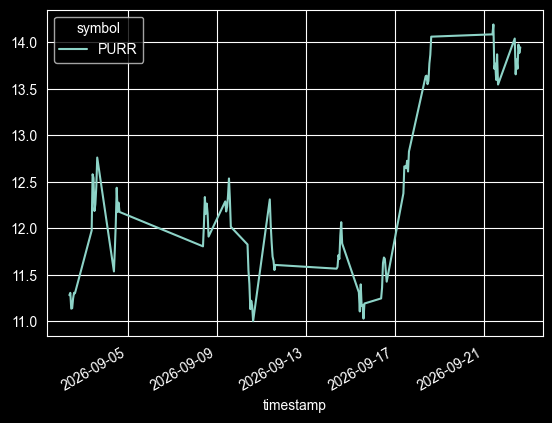

In [100]:
import matplotlib.pyplot as plt
from backtest.data import load_bars
panel = load_bars("PURR", "2026-09-02", "2026-09-22", timeframe="1Hour", session="regular")
close = panel.field("close")
close.plot()
plt.show()

`no_entry_print` is not a data failure — it means the contract never traded again
after the sweep that session, so there was no fill to take. Dropping those is the
honest treatment; filling at a price from before the signal existed would be
lookahead.

## 2. Baseline — direction only, no confirmation

Before testing your confirmation rule, the signal it is meant to improve on.

In [12]:
def summarise(frame, label):
    if not len(frame):
        return {"variant": label, "n": 0}
    ret = frame.ret
    return {"variant": label, "n": len(ret),
            "mean %": round(ret.mean() * 100, 1),
            "median %": round(ret.median() * 100, 1),
            "win %": round((ret > 0).mean() * 100, 1),
            "total P&L $1k ea": round(((ret) * 1000).sum()),
            "worst %": round(ret.min() * 100, 1),
            "best %": round(ret.max() * 100, 1)}

base = summarise(live, "all triggers (direction only)")
print(pd.DataFrame([base]).to_string(index=False))
print()
print("by direction:")
print(pd.DataFrame([summarise(live[live.direction == d], d) for d in ("BULL", "BEAR")]).to_string(index=False))

                      variant   n  mean %  median %  win %  total P&L $1k ea  worst %  best %
all triggers (direction only) 305    -5.4     -62.5   35.1            -16405   -100.0   397.6

by direction:
variant   n  mean %  median %  win %  total P&L $1k ea  worst %  best %
   BULL 165   -19.7     -88.6   29.7            -32561   -100.0   397.6
   BEAR 140    11.5     -48.0   41.4             16157   -100.0   397.1


In [14]:
live

,ticker,session,entry_ts,direction,sweep_premium,sweep_delta,entry_spot,prior_n_x,skip,expiry,right,strike,entry_price,entry_volume,exit_spot,exit_price,ret,contract_cost,prior_n_y,same_dir_n,opp_dir_n,net_dir_n,conviction,aligned
0,NOK,2026-06-01,2026-06-01 09:32:57.919,BEAR,1192500.0,0.428827,15.14,NaN,None,2026-06-18,PUT,15.0,0.92,5680.0,13.48,1.52,0.652174,92.0,0,0,0,0,NaN,NaN
1,IBM,2026-06-01,2026-06-01 09:38:42.728,BULL,3474531.0,0.579431,315.58,NaN,None,2026-06-18,CALL,320.0,18.00,2724.0,249.06,0.00,-1.000000,1800.0,0,0,0,0,NaN,NaN
2,MU,2026-06-01,2026-06-01 09:47:27.749,BULL,1968416.0,0.504677,1034.72,NaN,None,2026-06-18,CALL,1030.0,94.05,1202.0,1132.13,102.13,0.085912,9405.0,1,0,1,-1,-1.000000,-1.000000
3,NBIS,2026-06-01,2026-06-01 09:51:47.005,BEAR,1433380.0,0.463577,257.23,NaN,None,2026-06-18,PUT,255.0,26.06,35.0,287.10,0.00,-1.000000,2606.0,0,0,0,0,NaN,NaN
4,PLTR,2026-06-01,2026-06-01 09:57:23.368,BEAR,1135778.0,0.547273,159.71,NaN,None,2026-06-18,PUT,160.0,8.16,699.0,128.45,31.55,2.866422,816.0,0,0,0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414,MU,2026-09-10,2026-09-10 15:05:05.506,BULL,1338575.0,0.308963,979.82,NaN,None,2026-09-18,CALL,980.0,32.65,1187.0,1016.24,36.24,0.109954,3265.0,15,6,9,-3,-0.235549,-0.235549
415,AMD,2026-09-11,2026-09-11 09:30:08.509,BEAR,1653465.0,0.455456,510.54,NaN,None,2026-09-18,PUT,510.0,16.36,467.0,559.83,0.00,-1.000000,1636.0,0,0,0,0,NaN,NaN
416,META,2026-09-11,2026-09-11 09:43:57.509,BEAR,1793540.0,0.368775,660.61,NaN,None,2026-09-18,PUT,660.0,14.06,552.0,668.60,0.00,-1.000000,1406.0,1,1,0,1,-1.000000,1.000000
417,DELL,2026-09-11,2026-09-11 11:15:52.104,BULL,2909594.0,0.580899,558.86,NaN,None,2026-09-18,CALL,560.0,18.95,2507.0,569.07,9.07,-0.521372,1895.0,0,0,0,0,NaN,NaN


## 3. Your rule — count of same-direction sweeps

Point-in-time: only sweeps that printed **before** the trigger, on the same ticker,
in the same session.

In [4]:
rows = [summarise(live, "no filter (>=0)")]
for k in (1, 2, 3, 5, 8):
    rows.append(summarise(live[live.same_dir_n >= k], f"same_dir_n >= {k}"))
pd.DataFrame(rows)

,variant,n,mean %,median %,win %,total P&L $1k ea,worst %,best %
0,no filter (>=0),305,-5.4,-62.5,35.1,-16405,-100.0,397.6
1,same_dir_n >= 1,193,-10.4,-62.5,32.6,-20094,-100.0,397.6
2,same_dir_n >= 2,142,-11.3,-48.9,30.3,-16050,-100.0,397.6
3,same_dir_n >= 3,108,-0.5,-25.4,34.3,-564,-100.0,397.6
4,same_dir_n >= 5,65,-16.5,-32.4,29.2,-10694,-100.0,351.7
5,same_dir_n >= 8,34,5.4,-25.0,35.3,1843,-100.0,262.2


### The same rule, but signed

A raw same-direction count ignores how much flow went the *other* way. Ten agreeing
sweeps against twelve opposing is not confirmation. `net_dir_n` is the same count
minus the opposing one:

In [5]:
rows = [summarise(live, "no filter")]
for k in (0, 1, 2, 3, 5):
    rows.append(summarise(live[live.net_dir_n >= k], f"net_dir_n >= {k}"))
pd.DataFrame(rows)

,variant,n,mean %,median %,win %,total P&L $1k ea,worst %,best %
0,no filter,305,-5.4,-62.5,35.1,-16405,-100.0,397.6
1,net_dir_n >= 0,222,-6.8,-67.8,33.3,-15046,-100.0,397.6
2,net_dir_n >= 1,110,-6.2,-56.2,30.9,-6794,-100.0,397.6
3,net_dir_n >= 2,70,-12.6,-56.2,30.0,-8817,-100.0,397.6
4,net_dir_n >= 3,44,-5.7,-51.8,34.1,-2524,-100.0,397.6
5,net_dir_n >= 5,15,-4.5,-32.8,33.3,-668,-100.0,243.4


### And against the premium-weighted version

`aligned` is the share of prior premium leaning the trigger's way, in [-1, +1]. It is
scale-free, so one enormous print cannot manufacture agreement and a heavily-swept
mega-cap does not outrank a quiet name automatically.

In [6]:
rows = [summarise(live, "no filter")]
for k in (0.0, 0.25, 0.5, 0.75):
    rows.append(summarise(live[live.aligned >= k], f"aligned >= {k}"))
pd.DataFrame(rows)

,variant,n,mean %,median %,win %,total P&L $1k ea,worst %,best %
0,no filter,305,-5.4,-62.5,35.1,-16405,-100.0,397.6
1,aligned >= 0.0,133,-11.8,-62.5,31.6,-15631,-100.0,397.6
2,aligned >= 0.25,110,-17.8,-67.7,28.2,-19612,-100.0,397.6
3,aligned >= 0.5,78,-19.0,-100.0,29.5,-14830,-100.0,397.6
4,aligned >= 0.75,60,-23.4,-100.0,25.0,-14018,-100.0,397.6


## 4. Out of sample

Every table above is in-sample, and there are three filter families with several
thresholds each. That is more than enough surface to find something by accident, so
the only number worth weighting is one from a period the threshold was not chosen on.

The split is by date: everything before `OOS_SPLIT` is where a rule may be chosen,
everything after is where it is judged **once**.

In [7]:
train = live[live.session < OOS_SPLIT]
test = live[live.session >= OOS_SPLIT]
print(f"train {len(train)} positions ({train.session.min()} .. {train.session.max()})")
print(f"test  {len(test)} positions ({test.session.min()} .. {test.session.max()})")
print()

variants = {
    "direction only":     lambda f: f,
    "same_dir_n >= 2":    lambda f: f[f.same_dir_n >= 2],
    "same_dir_n >= 3":    lambda f: f[f.same_dir_n >= 3],
    "net_dir_n >= 1":     lambda f: f[f.net_dir_n >= 1],
    "aligned >= 0.5":     lambda f: f[f.aligned >= 0.5],
}
out = []
for name, fn in variants.items():
    tr, te = summarise(fn(train), name), summarise(fn(test), name)
    out.append({"variant": name,
                "train n": tr.get("n"), "train mean %": tr.get("mean %"), "train win %": tr.get("win %"),
                "test n": te.get("n"), "test mean %": te.get("mean %"), "test win %": te.get("win %")})
pd.DataFrame(out)

train 240 positions (2026-06-01 .. 2026-08-14)
test  65 positions (2026-08-17 .. 2026-09-11)



,variant,train n,train mean %,train win %,test n,test mean %,test win %
0,direction only,240,-2.6,37.1,65,-15.8,27.7
1,same_dir_n >= 2,116,-5.7,34.5,26,-36.2,11.5
2,same_dir_n >= 3,88,3.6,38.6,20,-18.8,15.0
3,net_dir_n >= 1,91,-3.1,35.2,19,-20.8,10.5
4,aligned >= 0.5,70,-15.5,31.4,8,-49.5,12.5


## 5. Reading this honestly

A few things to hold on to whatever the tables say.

**Options are lottery-shaped.** Mean return is dominated by the tail — a couple of
positions carry the number and the median sits well below the mean. Check `worst %`
and `best %`, and look at how much of the P&L comes from the top two trades before
believing any average.

**Hold-to-expiry is the full-risk version.** There is no stop and no target, so every
losing position goes to -100%. `backtest_strategy.py` shows that adding a target and
stop moved that strategy by ~97 points; the same is likely here, and untested.

**No costs are charged.** Entry is the first traded print after the sweep, which
assumes a fill at someone else's price with no spread paid. `bidAskSpread` rides along
in the flow cache if you want to charge the observed distribution.

**Capacity is unchecked.** `entry_volume` is the contract's session volume — a
position sized beyond what actually traded could not have been filled.

In [8]:
win, lose = live[live.ret > 0], live[live.ret <= 0]
print(f"winners {len(win):3}  gross +{win.ret.sum() * 100:,.0f} pts")
print(f"losers  {len(lose):3}  gross {lose.ret.sum() * 100:,.0f} pts")
print(f"top 2 winners = {live.ret.nlargest(2).sum() / win.ret.sum():.0%} of all winning return")
print()
print("largest winners:")
print(live.nlargest(6, "ret")[["ticker", "session", "direction", "strike",
                               "entry_price", "exit_spot", "ret", "entry_volume"]]
      .to_string(index=False))

winners 107  gross +14,564 pts
losers  198  gross -16,205 pts
top 2 winners = 5% of all winning return

largest winners:
ticker    session direction  strike  entry_price  exit_spot      ret  entry_volume
  NBIS 2026-06-09      BULL   205.0        16.50     287.10 3.975758          13.0
  MSFT 2026-06-02      BEAR   447.5        13.75     379.15 3.970909         277.0
  META 2026-08-26      BULL   570.0        20.20     668.60 3.881188        1107.0
  AAPL 2026-06-15      BULL   295.0         8.48     333.75 3.569575        1838.0
  SPCX 2026-07-09      BEAR   150.0         5.76     123.98 3.517361        5322.0
  COIN 2026-08-18      BULL   150.0        10.20     194.24 3.337255         720.0


The loss is **broad-based, not an outlier artefact**: 107 winners against 198 losers,
and the two biggest winners are only 5% of all winning return. A result carried by two
trades can be dismissed as noise. This one cannot — it is the shape of the whole
distribution.

## 6. The one result that is not about the signal

`BEAR` triggers returned +11.5% and `BULL` triggers -19.7%. That is the largest effect
in the notebook, and it is almost certainly **not** a property of sweeps.

The sample is 78 consecutive sessions — a single market regime. A strategy whose puts
paid and whose calls did not, over one four-month window, has discovered the direction
of that window. Splitting on direction here is indistinguishable from betting on the
period, and with one regime in the sample there is no way to separate them.

Treat it as a reason to extend the sample across regimes, not as a rule.

In [9]:
by_month = (live.assign(month=live.session.str[:7])
            .groupby(["month", "direction"])
            .agg(n=("ret", "size"), mean_pct=("ret", lambda r: round(r.mean() * 100, 1)))
            .unstack(fill_value=0))
by_month

n      mean_pct      
direction BEAR BULL     BEAR  BULL
month                             
2026-06     53   70     29.8 -33.0
2026-07     49   37     21.2 -40.6
2026-08     21   30     29.3  20.9
2026-09     17   28    -95.1  -2.6